In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

### Functions

In [2]:
def get_tier_prop_overall(dict_tier_prop_approved, flt_approval_rate):
    df_tmp = pd.DataFrame({
        'tier': dict_tier_prop_approved.keys(),
        'prop_approved': dict_tier_prop_approved.values(),
    })
    df_tmp['prop_overall'] = df_tmp['prop_approved'] * flt_approval_rate
    df_tmp['prop_overall_cumsum'] = df_tmp['prop_overall'].cumsum()
    dict_tier_prop_overall = dict(zip(df_tmp['tier'], df_tmp['prop_overall_cumsum']))
    return dict_tier_prop_overall

In [3]:
def tag_approve_decline(prop_rank, dict_tier_prop_overall):
    # tag tier
    if prop_rank <= dict_tier_prop_overall['A1']:
        return 'A1'
    elif prop_rank <= dict_tier_prop_overall['A']:
        return 'A'
    elif prop_rank <= dict_tier_prop_overall['B']:
        return 'B'
    elif prop_rank <= dict_tier_prop_overall['C']:
        return 'C'
    elif prop_rank <= dict_tier_prop_overall['D']:
        return 'D'
    else:
        return 'Decline'

### Constants

In [4]:
str_dirname_output = '/output'
int_n_values = 10000
# approval rate
flt_approval_rate = 0.20
# tier distribution of approvals
dict_tier_prop_approved = {
    'A1': 0.0918,
    'A': 0.1115,
    'B': 0.4321,
    'C': 0.2006,
    'D': 0.1640,
}
# get sum of proportion approved tiers to make sure it adds up to 100%
flt_sum_prop_approved = np.sum(list(dict_tier_prop_approved.values()))
if flt_sum_prop_approved != 1:
    raise ValueError('Error! The sum of the approved tier proportions must equal 1.0')
else:
    pass

### Output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [6]:
# simulate data for gen 12
flt_mean_genxii = 0.4539
flt_sd_genxii = 0.0626

# calculate the z-score corresponding to the 20th percentile of a normal distribution
flt_z_approval_rate = norm.ppf(flt_approval_rate)
flt_mean_overall = flt_mean_genxii - ((flt_z_approval_rate * flt_sd_genxii) / np.sqrt(flt_approval_rate))
flt_sd_overall = flt_sd_genxii * np.sqrt((1 - flt_approval_rate) / flt_approval_rate)
list_flt_ecnl_overall = list(np.random.normal(flt_mean_overall, flt_sd_overall, int_n_values))

In [7]:
df = pd.DataFrame({
    'flt_ecnl_mod': list_flt_ecnl_overall,
})
df.sort_values(by='flt_ecnl_mod', ascending=True, inplace=True)
df['rank'] = list(range(1, df.shape[0]+1))
df['prop_rank'] = df['rank'] / df.shape[0]
# show
df

,flt_ecnl_mod,rank,prop_rank
935,0.075736,1,0.0001
9156,0.121799,2,0.0002
3493,0.124708,3,0.0003
2369,0.132047,4,0.0004
6231,0.150878,5,0.0005
...,...,...,...
9151,0.969546,9996,0.9996
5401,0.978197,9997,0.9997
2836,1.002759,9998,0.9998
9820,1.017555,9999,0.9999


### Plot

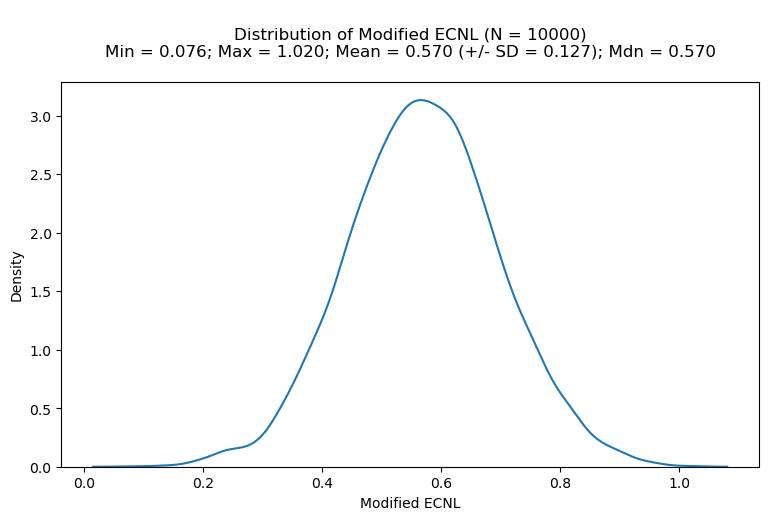

In [8]:
int_n = df.shape[0]
flt_min = df['flt_ecnl_mod'].min()
flt_max = df['flt_ecnl_mod'].max()
flt_mean = df['flt_ecnl_mod'].mean()
flt_sd = df['flt_ecnl_mod'].std()
flt_mdn = df['flt_ecnl_mod'].median()
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Modified ECNL (N = {int_n})
Min = {flt_min:0.3f}; Max = {flt_max:0.3f}; Mean = {flt_mean:0.3f} (+/- SD = {flt_sd:0.3f}); Mdn = {flt_mdn:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('Modified ECNL')
# plot
sns.kdeplot(list(df['flt_ecnl_mod']), ax=ax)
# show
plt.show()

### Convert approved tier proportions to overall tier proportions

In [9]:
dict_tier_prop_overall = get_tier_prop_overall(
    dict_tier_prop_approved=dict_tier_prop_approved, 
    flt_approval_rate=flt_approval_rate,
)
dict_tier_prop_overall

{'A1': 0.01836, 'A': 0.04066, 'B': 0.12708, 'C': 0.16720000000000002, 'D': 0.2}

### Assign tier

In [10]:
# sort ascending
df.sort_values(by='flt_ecnl_mod', ascending=True, inplace=True)
df['rank'] = list(range(1, df.shape[0]+1))
df['prop_rank'] = df['rank'] / df.shape[0]
df.drop('rank', axis=1, inplace=True)

# tag tier
df['tier'] = df['prop_rank'].apply(
    lambda x: tag_approve_decline(
        prop_rank=x, 
        dict_tier_prop_overall=dict_tier_prop_overall,
    ),
)

# show
df

,flt_ecnl_mod,prop_rank,tier
935,0.075736,0.0001,A1
9156,0.121799,0.0002,A1
3493,0.124708,0.0003,A1
2369,0.132047,0.0004,A1
6231,0.150878,0.0005,A1
...,...,...,...
9151,0.969546,0.9996,Decline
5401,0.978197,0.9997,Decline
2836,1.002759,0.9998,Decline
9820,1.017555,0.9999,Decline


### Make sure it checks out

In [11]:
ser_freq = df['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','prop']
df_freq

,tier,prop
0,Decline,0.8000
1,B,0.0864
2,C,0.0402
3,D,0.0328
4,A,0.0223
5,A1,0.0183


In [12]:
# rm decline
ser_freq = df[df['tier'] != 'Decline']['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','prop']
df_freq

,tier,prop
0,B,0.4320
1,C,0.2010
2,D,0.1640
3,A,0.1115
4,A1,0.0915


### Get thresholds

In [13]:
df_tmp = df[df['tier'] != 'Decline'].groupby(by='tier', as_index=False).agg({
    'flt_ecnl_mod': 'max',
})
dict_ecnl_mod_thresh = dict(zip(df_tmp['tier'], df_tmp['flt_ecnl_mod']))
dict_ecnl_mod_thresh

{'A': 0.35174816328081504,
 'A1': 0.3078774012389497,
 'B': 0.42895983189564657,
 'C': 0.4499395982201206,
 'D': 0.4649724964050279}

### Plot

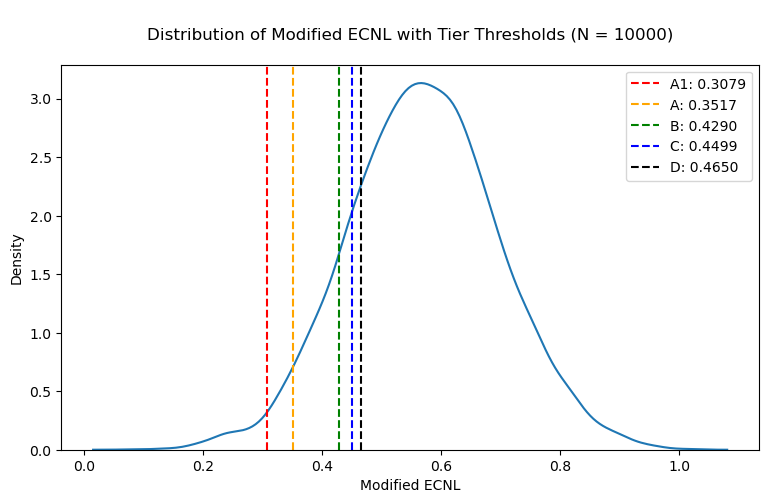

In [14]:
list_str_tier = [
    'A1',
    'A',
    'B',
    'C',
    'D',
]
list_str_colors = [
    'red',
    'orange',
    'green',
    'blue',
    'black',
]
int_n = df.shape[0]
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Modified ECNL with Tier Thresholds (N = {int_n})
"""
ax.set_title(str_title)
ax.set_xlabel('Modified ECNL')
# plot
sns.kdeplot(list(df['flt_ecnl_mod']), ax=ax)
# add threshold lines
for a, str_tier in enumerate(list_str_tier):
    flt_thresh = dict_ecnl_mod_thresh[str_tier]
    ax.axvline(flt_thresh, linestyle='--', color=list_str_colors[a], label=f'{str_tier}: {flt_thresh:0.4f}')
# legend
plt.legend()
# show
plt.show()